In [50]:
# =========================
# 1. IMPORT LIBRARIES
# =========================

# Data handling
import pandas as pd
import numpy as np
#
# ML preprocessing & evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model
import sklearn
from sklearn.ensemble import RandomForestClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.pipeline import Pipeline
# OR if you aren't using imbalanced-learn samplers (like SMOTE):
# from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

# Model saving
import joblib



In [51]:
# =========================
# 2. LOAD DATA
# =========================

df = pd.read_csv("healthcare_disease_prediction_dataset.csv")
print("First rows:")
print(df.head())

print("last rows:")
print(df.tail())

print("\nDataset Info:")
print(df.info())
print("summary information:")
print(df.describe())



First rows:
   Age  Gender  Alzheimer's Disease Blood Pressure Cholesterol Glucose  \
0   69    Male                    0           High        High    High   
1   32    Male                    0            Low        High  Normal   
2   89  Female                    0         Normal        High  Normal   
3   78    Male                    0           High        High    High   
4   38    Male                    0            Low      Normal  Normal   

  Smoking Alcohol Consumption Exercise        BMI Family History  \
0     Yes                  No       No  35.671099             No   
1     Yes                  No      Yes  38.554188            Yes   
2      No                  No      Yes  18.932964            Yes   
3      No                  No      Yes  21.806350            Yes   
4     Yes                 Yes      Yes  37.552683             No   

   Heart Disease  Diabetes  Stroke  Kidney Disease  Cancer  COPD  \
0              1         0       0               0       1     0  

In [52]:
# =========================
# 3. CLEAN COLUMN NAMES
# =========================

# Remove hidden spaces in column names
df.columns = df.columns.str.strip()



In [53]:
# =========================
# 4. CLEAN TARGET COLUMN
# =========================

# Normalize text (case + spaces)
df["Diabetes"] = (
    df["Diabetes"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [54]:
# Remove duplicates
df = df.drop_duplicates()

In [55]:
df["Diabetes"] = df["Diabetes"].astype(str).str.strip().str.lower()

In [56]:

print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   int64  
 1   Gender               1000 non-null   str    
 2   Alzheimer's Disease  1000 non-null   int64  
 3   Blood Pressure       1000 non-null   str    
 4   Cholesterol          1000 non-null   str    
 5   Glucose              1000 non-null   str    
 6   Smoking              1000 non-null   str    
 7   Alcohol Consumption  1000 non-null   str    
 8   Exercise             1000 non-null   str    
 9   BMI                  1000 non-null   float64
 10  Family History       1000 non-null   str    
 11  Heart Disease        1000 non-null   int64  
 12  Diabetes             1000 non-null   str    
 13  Stroke               1000 non-null   int64  
 14  Kidney Disease       1000 non-null   int64  
 15  Cancer               1000 non-null 

In [57]:
# =========================
# 5. CLEAN FEATURES
# =========================

feature_cols = [
     "Age","Gender","Alzheimer's Disease","Blood Pressure","Cholesterol","Glucose","Smoking","Alcohol Consumption","Exercise","BMI","Family History","Heart Disease","Stroke","Kidney Disease","Cancer","COPD","Liver Disease","Parkinson's Disease","Tuberculosis"
     ]
df = df.dropna(subset=["Diabetes"])


In [58]:
# =========================
# 6. SPLIT DATA
# =========================

X = df[feature_cols]  # Inputs (symptoms)
y = df["Diabetes"]     # Target (labels)

In [59]:
# =========================
# 7. LABEL ENCODING
# =========================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Show mapping
print("\nClass mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{i} -> {cls}")


Class mapping:
0 -> 0
1 -> 1


In [60]:
 # =========================
# 8. TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # keeps class balance
)

In [61]:
# =========================
# 9. SMOTE (BALANCING)
# =========================

smote = SMOTE(random_state=42, k_neighbors=2)

In [62]:
# =========================
# 10. SCALING
# =========================

scaler = StandardScaler()

In [63]:
# =========================
# 11. MODEL
# =========================

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

In [64]:
# =========================
# 12. PIPELINE
# =========================

pipeline = ImbPipeline(steps=[
    ("scaler", scaler),
    ("smote", smote),
    ("model", model)
])

In [66]:


# 1. Identify your columns
categorical_cols = ["Gender","Blood Pressure","Cholesterol","Glucose","Smoking","Alcohol Consumption","Exercise","Family History"] # list your string columns
numerical_cols = ["Age","Alzheimer's Disease","BMI","Heart Disease","Stroke","Kidney Disease","Cancer","COPD","Liver Disease","Parkinson's Disease","Tuberculosis"]         # list your number columns

# 2. Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

# 3. Add the preprocessor to your pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier()) # or your specific model
])

# 4. Now cross_val_score will work!
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv)

print("\nCV Scores:", cv_scores)


print("Mean CV F1:", cv_scores.mean())


CV Scores: [0.80625 0.8125  0.80625 0.8125  0.8    ]
Mean CV F1: 0.8074999999999999


In [67]:
# =========================
# 14. TRAIN MODEL
# =========================

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

In [68]:
# =========================
# 15. PREDICTIONS
# =========================

y_pred = pipeline.predict(X_test)

In [69]:
# =========================
# 16. EVALUATION REPORT
# =========================

print("\nCLASSIFICATION REPORT:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))


CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.81      0.99      0.89       163
           1       0.00      0.00      0.00        37

    accuracy                           0.81       200
   macro avg       0.41      0.49      0.45       200
weighted avg       0.66      0.81      0.73       200



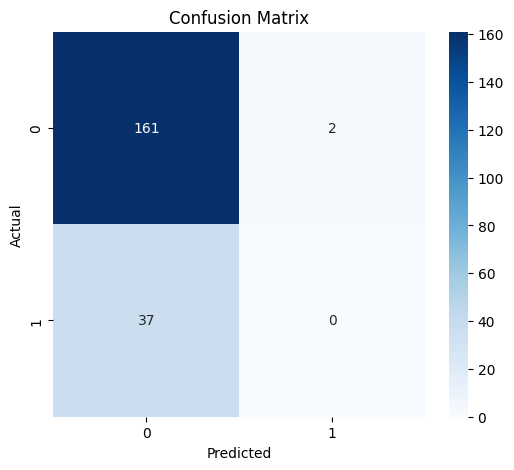

In [70]:
# =========================
# 17. CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [71]:
# =========================
# 18. FEATURE IMPORTANCE
# =========================

importances = pipeline.named_steps["model"].feature_importances_

plt.figure(figsize=(8, 6))
plt.barh(feature_cols, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

KeyError: 'model'